In [ ]:
# using statsmodels. also prob ignore.

In [ ]:
import pandas as pd
from darts import TimeSeries
from darts.utils.missing_values import fill_missing_values, missing_values_ratio
from darts.dataprocessing.transformers import MissingValuesFiller
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df_pivot = pd.read_csv('Daily_Means_Through_2022_cleaned_NEW.csv')
df_pivot

In [ ]:
# housekeeping
df_pivot['date'] = pd.to_datetime(df_pivot['date'])
df_new = df_pivot.sort_values(by=['site', 'date'])
df_new

In [ ]:
df_pp = df_new[df_new['site'] == 'PP']
df_pp

In [ ]:
do_series = df_pp.set_index("date")["bottom_DO_mg/L"]
do_series

In [ ]:
do_series.isnull().sum()

In [ ]:
# # ADF TEST
# do_series.fillna(value=7, inplace=True)
# result = adfuller(do_series, autolag='AIC')
# print(f'ADF Statistic: {result[0]}')
# print(f'n_lags: {result[1]}')
# print(f'p-value: {result[1]}')
# for key, value in result[4].items():
#     print('Critial Values:')
#     print(f'   {key}, {value}')    

# # yay stationary

# do_series.plot()

In [ ]:
full_date_range = pd.date_range(start=do_series.index.min(), end=do_series.index.max(), freq='D')

# Find missing dates
missing_dates = full_date_range.difference(do_series.index)
print(f"Missing dates: {missing_dates}")
print(f"Number of missing dates: {len(missing_dates)}")
print(f"Missing values ratio (missing/total): {len(missing_dates) / len(full_date_range)}")

In [ ]:
sites = df_new['site'].unique()

for site in sites:
    df_site = df_new[df_new['site'] == site]
    do_series = df_site.set_index("date")["bottom_DO_mg/L"]
    
    full_date_range = pd.date_range(start=do_series.index.min(), end=do_series.index.max(), freq='D')

    # Find missing dates
    missing_dates = full_date_range.difference(do_series.index)
    print(f"Missing dates: {missing_dates}")
    print(f"Number of missing dates: {len(missing_dates)}")
    print(f"Missing dates ratio (missing/total) for site {site}: {len(missing_dates) / len(full_date_range)}")

In [ ]:
# so TW is actually continous

df_tw = df_new[df_new['site'] == 'TW']
do_series = df_tw.set_index("date")["bottom_DO_mg/L"]
do_series

In [ ]:
train_size = int(len(do_series) * 0.8)  # Use 80% for training and 20% for testing
train_data, test_data = do_series[:train_size], do_series[train_size:]

train_data

In [ ]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(ds):
    result=adfuller(ds)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("P value is less than 0.05 that means we can reject the null hypothesis(Ho). Therefore we can conclude that data has no unit root and is stationary")
    else:
        print("Weak evidence against null hypothesis that means time series has a unit root which indicates that it is non-stationary ")

In [ ]:
adfuller_test(do_series.interpolate())


In [ ]:
do_series = do_series.interpolate()

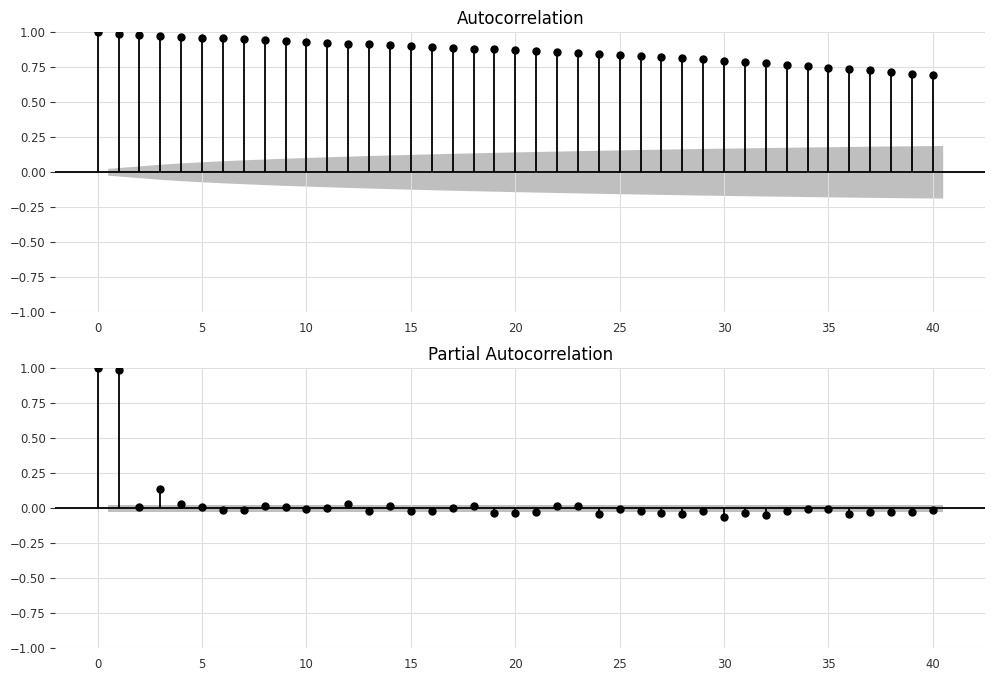

In [ ]:
fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(do_series,lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(do_series,lags=40,ax=ax2)

In [ ]:
do_series.index = pd.DatetimeIndex(do_series.index).to_period('D')
test_data.index = pd.DatetimeIndex(test_data.index).to_period('D')
train_data.index = pd.DatetimeIndex(train_data.index).to_period('D')

In [ ]:
model = ARIMA(train_data, order=(3, 0, 2), freq='D')
model_fit = model.fit()

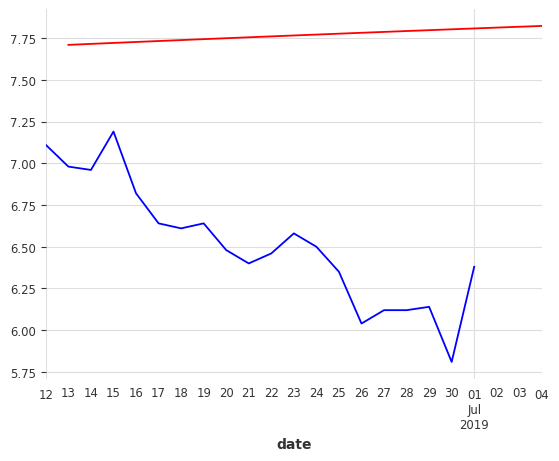

In [ ]:
forecast = model_fit.predict(start=len(train_data)+80, end=len(train_data) + 101)
forecast.plot(label='Forecast', color='red')
test_data[1:21].plot(label='Actual', color='blue')
#train_data.plot(label='Train', color='green')


In [ ]:
from pmdarima import auto_arima

In [ ]:
train_data.isna().sum()

print(train_data)
train_data = train_data.interpolate()

In [ ]:
# model = auto_arima(train_data, 
#                    seasonal=True,    # Use seasonal component
#                    m=365,             # m is the seasonal period, 12 for monthly seasonality (for yearly data)
#                    stepwise=True,    # Use stepwise search for optimal parameters
#                    trace=True)       # Display the progress of model selection

# # Display the summary of the model
# print(model.summary())

In [ ]:
from prophet import Prophet

In [ ]:
train_data = do_series

In [ ]:
new_df = pd.DataFrame()
new_df['ds'] = train_data.index.to_timestamp()
new_df['y'] = train_data.values
# ds to timestamp()
# new_df['ds'] = pd.to_datetime(new_df['ds'])
# new_df['ds']
new_df

In [ ]:
m = Prophet(changepoint_prior_scale=0.001, seasonality_prior_scale=0.01)
m.fit(new_df)

In [ ]:
future = m.make_future_dataframe(periods=365)
future.tail()

In [ ]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

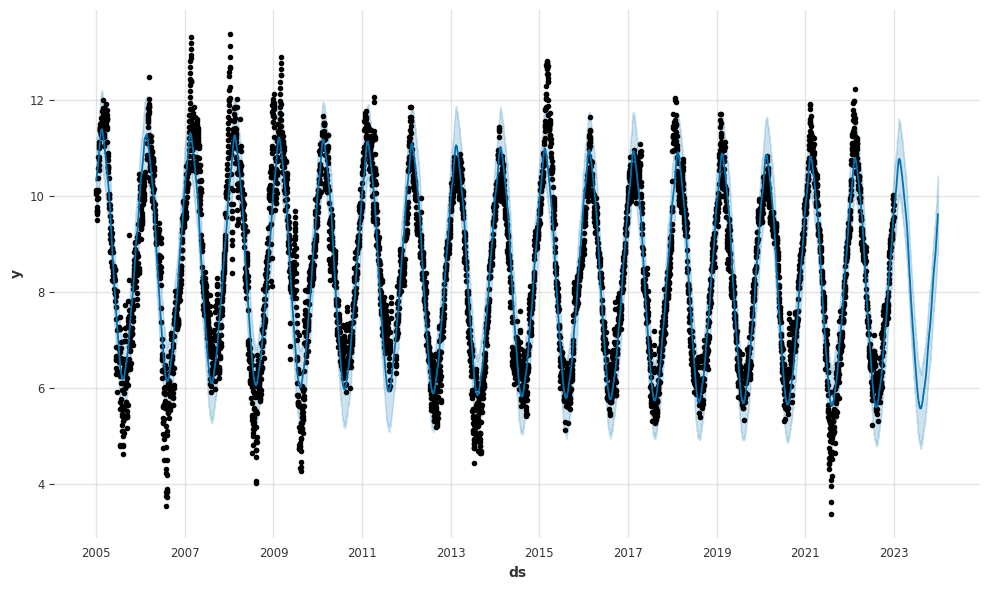

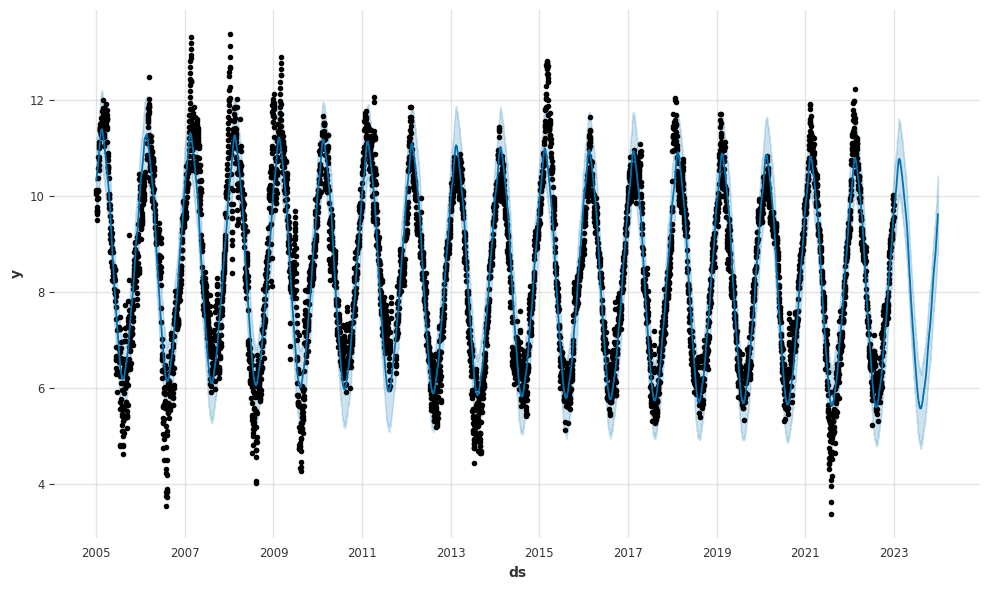

In [ ]:
fig1 = m.plot(forecast)
fig1

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

In [ ]:
plot_plotly(m, forecast)

In [ ]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(m, initial='730 days', period='180 days', horizon = '365 days', parallel="processes")
df_cv.head()

In [ ]:
# Python
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

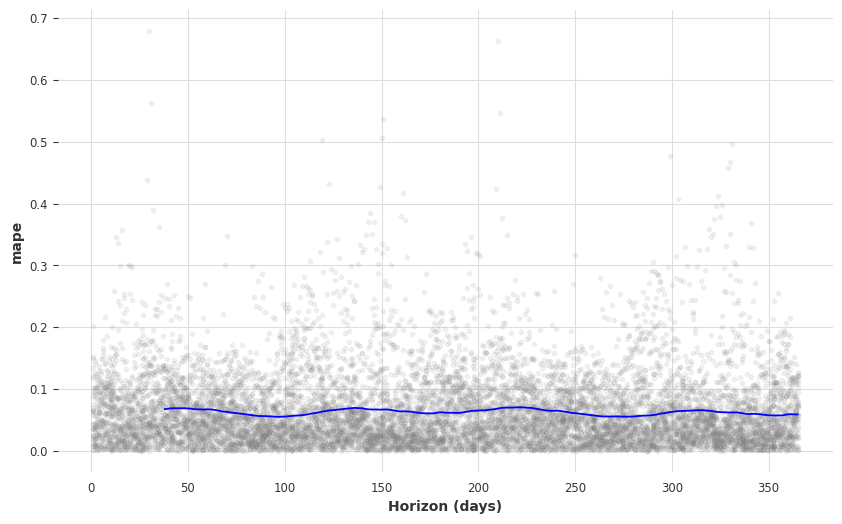

In [ ]:
# Python
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='mape')
print(fig)

In [ ]:
# Python
import itertools
import numpy as np
import pandas as pd

param_grid = {  
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0],
}

# Generate all combinations of parameters
all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
rmses = []  # Store the RMSEs for each params here

# Use cross validation to evaluate all parameters
for params in all_params:
    m = Prophet(**params).fit(new_df)  # Fit model with given params
    df_cv = cross_validation(m, initial='730 days', period='180 days', horizon = '180 days', parallel="processes")
    df_p = performance_metrics(df_cv, rolling_window=1)
    rmses.append(df_p['rmse'].values[0])

# Find the best parameters
tuning_results = pd.DataFrame(all_params)
tuning_results['rmse'] = rmses
print(tuning_results)

In [ ]:
best_params = all_params[np.argmin(rmses)]
print(best_params)

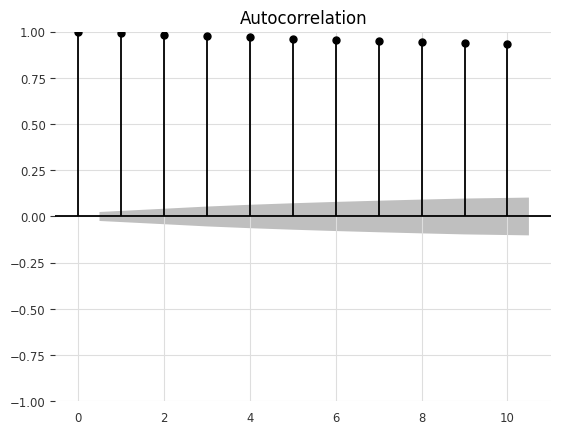

In [ ]:
# plot ACF 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
print(plot_acf(do_series.interpolate(), lags=10))
#print(plot_pacf(do_series.interpolate(), lags=3, alpha=0.05))

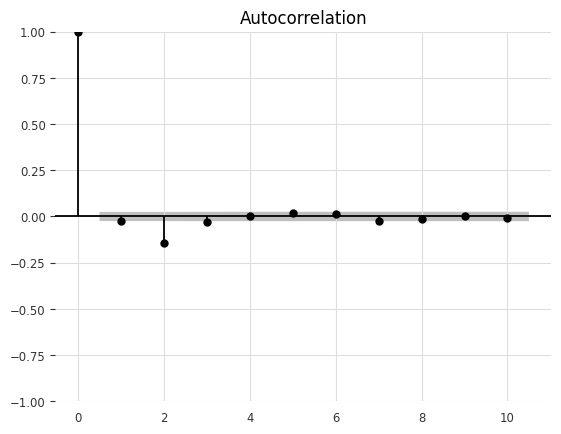

In [ ]:
diff_data = do_series.diff().dropna()
print(plot_acf(diff_data, lags=10))
